# Imports and configs

In [1]:
from hill_climbing import Climber, ClimberCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import joblib
import glob

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    train_path = "/kaggle/input/playground-series-s4e12/train.csv"
    test_path = "/kaggle/input/playground-series-s4e12/test.csv"
    sample_sub_path = "/kaggle/input/playground-series-s4e12/sample_submission.csv"

    oof_path = "/kaggle/input/hill-climbing-example-datasets/regression"
    
    target = "Premium Amount"
    n_folds = 10
    seed = 42

# Loading data and OOF files

In [3]:
train = pd.read_csv(CFG.train_path, index_col="id")
X, y = train.drop(CFG.target, axis=1), np.log1p(train[CFG.target])

In [4]:
scores, oof_preds, test_preds = {}, {}, {}

In [5]:
paths = glob.glob(f"{CFG.oof_path}/*")
for path in paths:
    files = glob.glob(f"{path}/*")
    temp_oof_preds = joblib.load([file for file in files if "oof_preds" in file and "Zone" not in file][0])
    temp_test_preds = joblib.load([file for file in files if "test_preds" in file and "Zone" not in file][0])
    temp_oof_preds = np.log1p(temp_oof_preds)
    temp_test_preds = np.log1p(temp_test_preds)
    model_name = path.split("/")[-1]
        
    temp_scores = []        
    kf = KFold(n_splits=CFG.n_folds, random_state=CFG.seed, shuffle=True)
    for _, val_idx in kf.split(X, y):
        temp_scores.append(np.sqrt(mean_squared_error(y[val_idx], temp_oof_preds[val_idx])))
    
    scores[model_name] = temp_scores
    oof_preds[model_name] = temp_oof_preds
    test_preds[model_name] = temp_test_preds

# Hill climbing

In [6]:
X = pd.DataFrame(oof_preds)
X_test = pd.DataFrame(test_preds)

In [7]:
X.head()

,ydf,lgbm-gbdt,xgb,cb,lgbm-goss,histgb
0,6.885367,6.887116,6.872048,6.913801,6.886948,6.868694
1,6.464658,6.567122,6.589889,6.589576,6.569815,6.599147
2,6.720666,6.719123,6.709628,6.686528,6.718227,6.705565
3,6.698316,6.657095,6.680104,6.596375,6.693564,6.673234
4,6.680474,6.667575,6.666809,6.675355,6.674154,6.679302


In [8]:
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [9]:
climber = Climber(
    objective="minimize",
    eval_metric=rmsle,
    allow_negative_weights=True,
    precision=0.001,
    score_decimal_places=5
)

In [10]:
climber.fit(X, y)

╔══════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                          Configuration                                           ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════╝
 Metric ..................................................................................... rmsle
 Objective ............................................................................... minimize
 Precision .................................................................................. 0.001
 Allow negative weights ...................................................................... True
 Starting model .............................................................................. best
 Number of parallel jobs ....................................................................... 12
 Number of models ...............................................................................

In [11]:
scores["climber"] = [climber.best_score] * CFG.n_folds

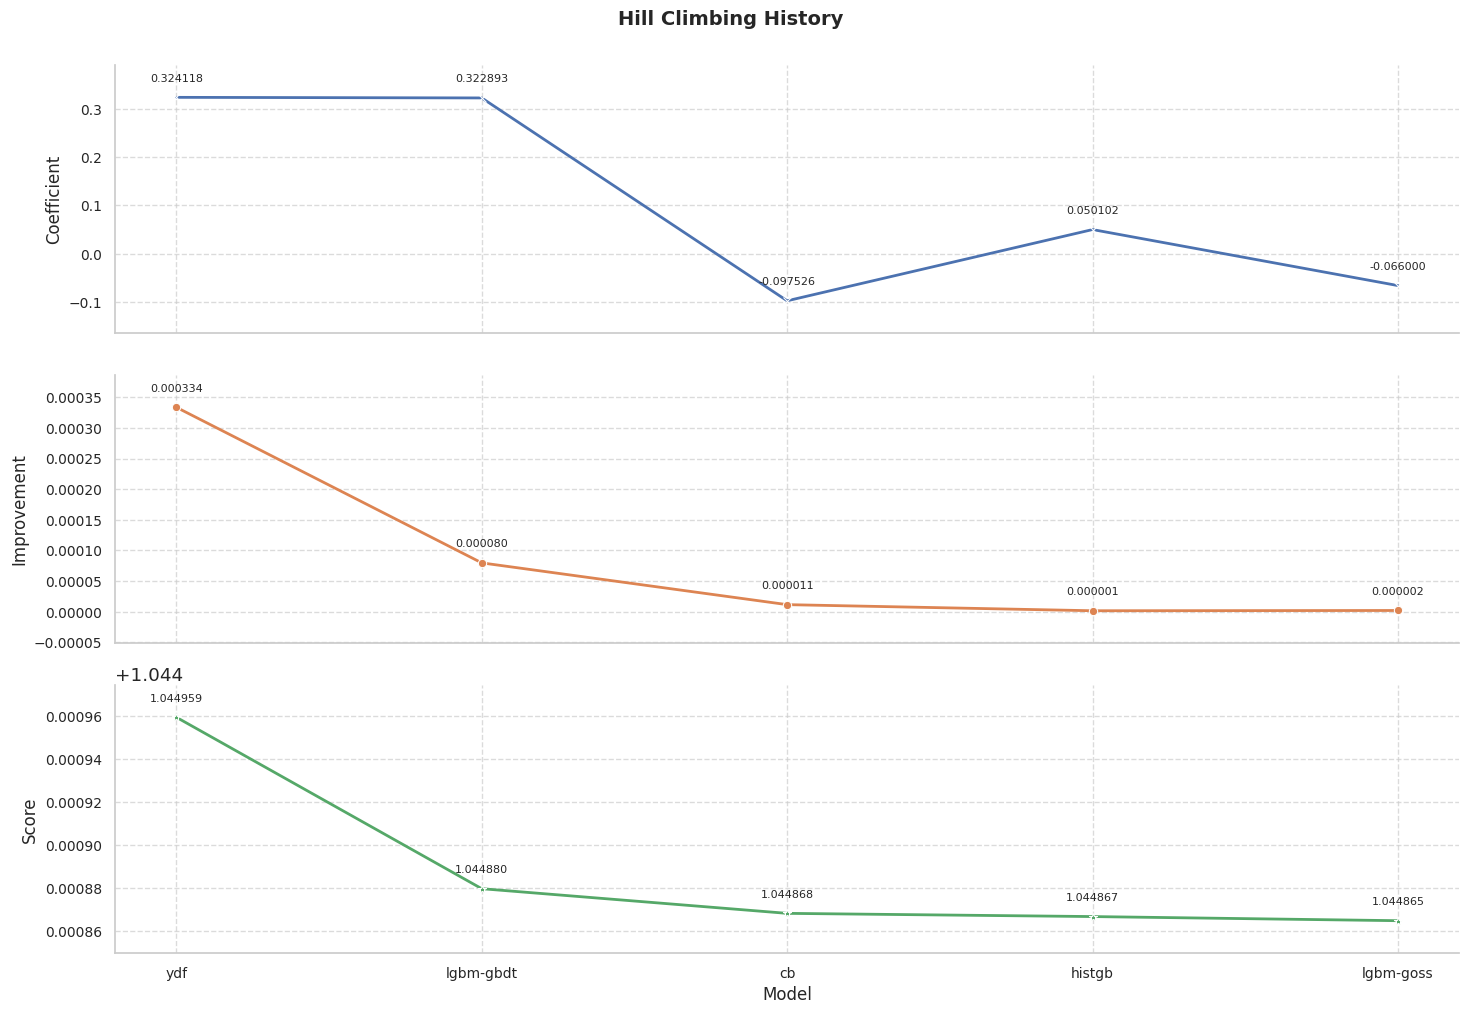

In [12]:
sns.set_style("whitegrid", {'grid.linestyle': '--'})
sns.set_context("notebook", font_scale=1.2)

def add_annotations(ax, x, y):
    for xi, yi in zip(x, y):
        ax.annotate(
            f'{yi:.6f}', (xi, yi),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            va='bottom',
            fontsize=8
        )

palette = sns.color_palette("deep")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

sns.lineplot(x=climber.history.model[1:], y=climber.history.coef[1:], color=palette[0], marker='x', ax=ax1, linewidth=2)
add_annotations(ax1, climber.history.model[1:], climber.history.coef[1:])
ax1.set_ylabel('Coefficient', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=climber.history.model[1:], y=climber.history.improvement[1:], color=palette[1], marker='o', ax=ax2, linewidth=2)
add_annotations(ax2, climber.history.model[1:], climber.history.improvement[1:])
ax2.set_ylabel('Improvement', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=climber.history.model[1:], y=climber.history.score[1:], color=palette[2], marker='*', ax=ax3, linewidth=2)
add_annotations(ax3, climber.history.model[1:], climber.history.score[1:])
ax3.set_ylabel('Score', fontsize=12)
ax3.set_xlabel('Model', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle('Hill Climbing History', y=1.02, fontsize=14, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - (ymax-ymin)*0.1, ymax + (ymax-ymin)*0.1)

plt.show()

## Predicting on the test set

In [13]:
preds = climber.predict(X_test)
preds[:25]

array([6.73332901, 6.69143907, 6.67229681, 6.69356086, 6.62680954,
       6.67867806, 6.88277755, 6.53768375, 5.28352937, 6.71665687,
       6.86733643, 6.68877758, 6.70206364, 6.68409111, 6.62110496,
       6.65578551, 6.7056217 , 5.26118894, 6.7148376 , 6.59381623,
       6.76244079, 6.6922176 , 5.35407683, 6.70135754, 6.72915207])

# Hill climbing with cross-validation

In [14]:
climber_cv = ClimberCV(
    objective="minimize",
    eval_metric=rmsle,
    allow_negative_weights=True,
    precision=0.001,
    score_decimal_places=5,
    cv=KFold(n_splits=CFG.n_folds, random_state=CFG.seed, shuffle=True),
)

In [15]:
climber_cv.fit(X, y)

╔══════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                          Configuration                                           ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════╝
 Metric ..................................................................................... rmsle
 Objective ............................................................................... minimize
 Precision .................................................................................. 0.001
 Allow negative weights ...................................................................... True
 Starting model .............................................................................. best
 Number of parallel jobs ....................................................................... 12
 Number of models ...............................................................................

In [16]:
scores["climber-cv"] = climber_cv.fold_scores

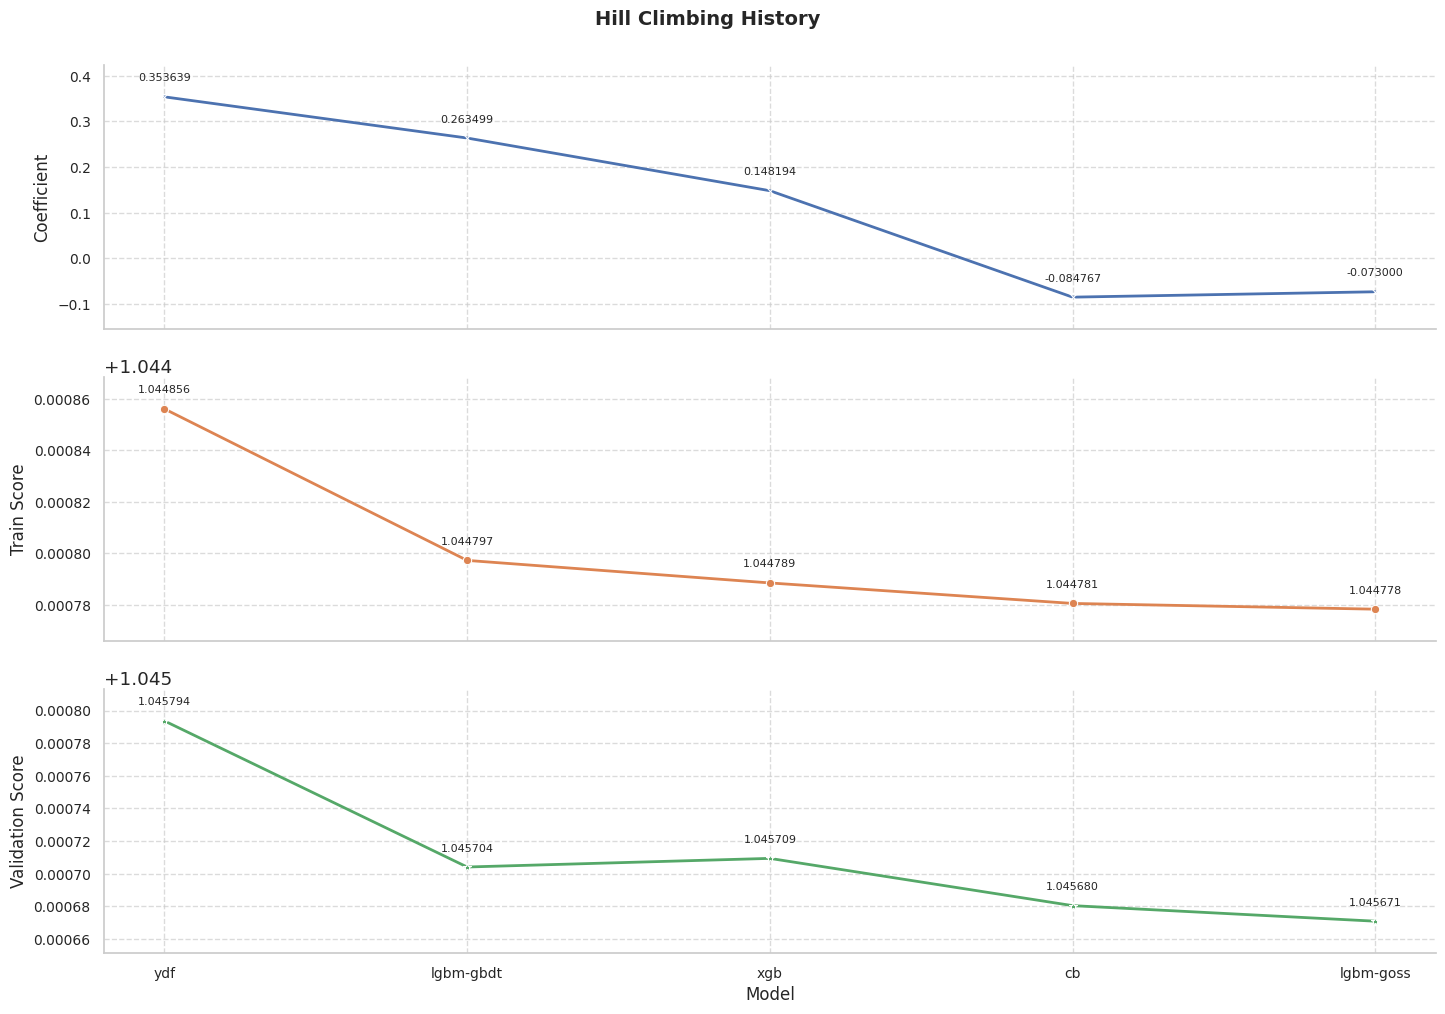

In [17]:
fold_1_history = climber_cv.history[climber_cv.history.fold == 1]

palette = sns.color_palette("deep")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.coef[1:], color=palette[0], marker='x', ax=ax1, linewidth=2)
add_annotations(ax1, fold_1_history.model[1:], fold_1_history.coef[1:])
ax1.set_ylabel('Coefficient', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.train_score[1:], color=palette[1], marker='o', ax=ax2, linewidth=2)
add_annotations(ax2, fold_1_history.model[1:], fold_1_history.train_score[1:])
ax2.set_ylabel('Train Score', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

sns.lineplot(x=fold_1_history.model[1:], y=fold_1_history.val_score[1:], color=palette[2], marker='*', ax=ax3, linewidth=2)
add_annotations(ax3, fold_1_history.model[1:], fold_1_history.val_score[1:])
ax3.set_ylabel('Validation Score', fontsize=12)
ax3.set_xlabel('Model', fontsize=12)
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.suptitle('Hill Climbing History', y=1.02, fontsize=14, fontweight='bold')

for ax in [ax1, ax2, ax3]:
    ax.tick_params(labelsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(True, linestyle='--', alpha=0.7)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - (ymax-ymin)*0.1, ymax + (ymax-ymin)*0.1)

plt.show()

## Predicting on the test set

In [18]:
preds = climber_cv.predict(X_test)
preds[:25]

array([6.74022001, 6.69265301, 6.67141033, 6.69430109, 6.62609118,
       6.67769329, 6.88270477, 6.5373074 , 5.28426165, 6.71717856,
       6.86668191, 6.68952095, 6.7019604 , 6.68402107, 6.6218028 ,
       6.64305711, 6.70520864, 5.26200452, 6.71405297, 6.59275299,
       6.76371161, 6.69263049, 5.3548572 , 6.69779447, 6.73158407])

# Results

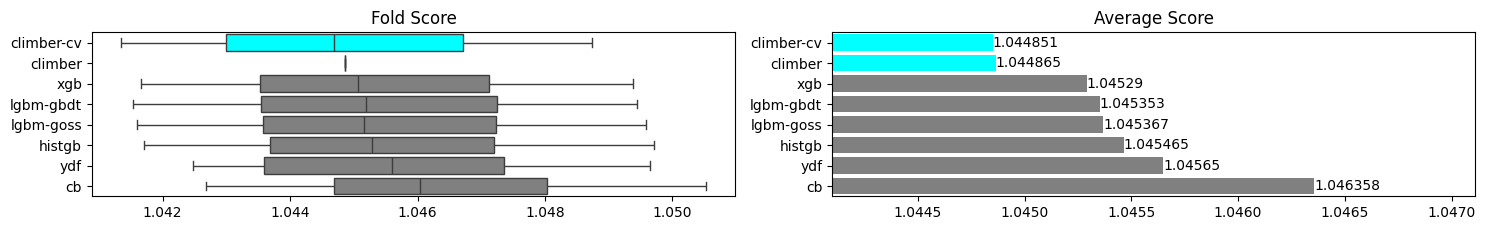

In [19]:
sns.reset_defaults()

scores = pd.DataFrame(scores)
mean_scores = scores.mean().sort_values(ascending=True)
order = scores.mean().sort_values(ascending=True).index.tolist()

min_score = mean_scores.min()
max_score = mean_scores.max()
padding = (max_score - min_score) * 0.5
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, scores.shape[1] * 0.3))

boxplot = sns.boxplot(data=scores, order=order, ax=axs[0], orient='h', color='grey')
axs[0].set_title('Fold Score')
axs[0].set_xlabel('')
axs[0].set_ylabel('')

barplot = sns.barplot(x=mean_scores.values, y=mean_scores.index, ax=axs[1], color='grey')
axs[1].set_title('Average Score')
axs[1].set_xlabel('')
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel('')

for i, (score, model) in enumerate(zip(mean_scores.values, mean_scores.index)):
    color = 'cyan' if 'climber' in model.lower() else 'grey'
    barplot.patches[i].set_facecolor(color)
    boxplot.patches[i].set_facecolor(color)
    barplot.text(score, i, round(score, 6), va='center')

plt.tight_layout()
plt.show()